In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/online_retail_clean.csv")

print(df.shape)
print(df.columns)
df.head()

(400916, 10)
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country', 'Month', 'Sales'],
      dtype='object')


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Month,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-12,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-12,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-12,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-12,30.0


In [2]:
print(df.columns.tolist())

['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Month', 'Sales']


In [3]:
df["Invoice"].astype(str).str.startswith("C").sum()

np.int64(0)

In [4]:
df = df[df["Quantity"] > 0]

In [5]:
df = df.dropna(subset=["Description"])

In [6]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


# creating basket

In [7]:
basket = (
    df.groupby(["Invoice", "Description"])["Quantity"]
      .sum()
      .unstack()
      .fillna(0)
)

basket.head()

Description,DOORMAT UNION JACK GUNS AND ROSES,3 STRIPEY MICE FELTCRAFT,4 PURPLE FLOCK DINNER CANDLES,ANIMAL STICKERS,BLACK PIRATE TREASURE CHEST,BROWN PIRATE TREASURE CHEST,Bank Charges,CAMPHOR WOOD PORTOBELLO MUSHROOM,CHERRY BLOSSOM DECORATIVE FLASK,FAIRY CAKE CANDLES,...,ZINC HEART LATTICE CHARGER LARGE,ZINC HEART LATTICE CHARGER SMALL,ZINC HEART LATTICE DOUBLE PLANTER,ZINC HEART LATTICE PLANTER BOWL,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC HEART LATTICE TRAY OVAL,ZINC METAL HEART DECORATION,ZINC POLICE BOX LANTERN,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489435,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489436,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
489438,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
basket = basket.map(lambda x: 1 if x > 0 else 0)

In [12]:
basket = basket.astype(bool)
basket.dtypes.value_counts()

bool    4444
Name: count, dtype: int64

In [14]:
from mlxtend.frequent_patterns import fpgrowth

frequent_itemsets = fpgrowth(
    basket,
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.069484,(STRAWBERRY CERAMIC TRINKET BOX)
1,0.018321,(SAVE THE PLANET MUG)
2,0.016707,(PINK DOUGHNUT TRINKET POT )
3,0.012127,(15CM CHRISTMAS GLASS BALL 20 LIGHTS)
4,0.011867,(PINK CHERRY LIGHTS)


In [15]:
frequent_itemsets = frequent_itemsets.sort_values(
    by="support",
    ascending=False
)

frequent_itemsets.head(20)

,support,itemsets
45,0.157237,(WHITE HANGING HEART T-LIGHT HOLDER)
464,0.087805,(REGENCY CAKESTAND 3 TIER)
0,0.069484,(STRAWBERRY CERAMIC TRINKET BOX)
6,0.069380,(ASSORTED COLOUR BIRD ORNAMENT)
7,0.061104,(HOME BUILDING BLOCK WORD)
83,0.060376,(PACK OF 72 RETRO SPOT CAKE CASES)
79,0.059127,(60 TEATIME FAIRY CAKE CASES)
524,0.055171,(JUMBO BAG RED RETROSPOT)
58,0.055067,(LUNCH BAG RED SPOTTY)
193,0.054182,(REX CASH+CARRY JUMBO SHOPPER)


In [16]:
from mlxtend.frequent_patterns import association_rules

In [18]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(RED HANGING HEART T-LIGHT HOLDER),(WHITE HANGING HEART T-LIGHT HOLDER),0.051736,0.157237,0.037579,0.726358,4.619503,1.0,0.029444,3.079802,0.826274,0.219253,0.675304,0.482676
1,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.042055,0.069484,0.032374,0.769802,11.078806,1.0,0.029452,4.042241,0.949676,0.408941,0.752612,0.617860
2,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE ),0.042575,0.052517,0.028835,0.677262,12.896162,1.0,0.026599,2.935763,0.963478,0.435192,0.659373,0.613160
3,(WOODEN FRAME ANTIQUE WHITE ),(WOODEN PICTURE FRAME WHITE FINISH),0.052517,0.042575,0.028835,0.549058,12.896162,1.0,0.026599,2.123168,0.973587,0.435192,0.529006,0.613160
4,(LOVE BUILDING BLOCK WORD),(HOME BUILDING BLOCK WORD),0.049394,0.061104,0.027169,0.550053,9.001842,1.0,0.024151,2.086679,0.935100,0.326046,0.520770,0.497343


In [19]:
strong_rules = rules[
    (rules["confidence"] >= 0.5) &
    (rules["lift"] > 1)
]

In [20]:
strong_rules = strong_rules.sort_values(
    by="lift",
    ascending=False
)

In [21]:
top_rules = strong_rules.head(20)

top_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

,antecedents,consequents,support,confidence,lift
122,(CHILDS GARDEN TROWEL PINK),(CHILDS GARDEN TROWEL BLUE ),0.010097,0.839827,72.682852
121,(CHILDS GARDEN TROWEL BLUE ),(CHILDS GARDEN TROWEL PINK),0.010097,0.873874,72.682852
111,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE LIVINGROOM ),0.010201,0.725926,60.904868
110,(POPPY'S PLAYHOUSE LIVINGROOM ),(POPPY'S PLAYHOUSE BEDROOM ),0.010201,0.855895,60.904868
81,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE LIVINGROOM ),0.011034,0.709030,59.487316
82,(POPPY'S PLAYHOUSE LIVINGROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.011034,0.925764,59.487316
51,(POPPY'S PLAYHOUSE BEDROOM ),(POPPY'S PLAYHOUSE KITCHEN),0.012648,0.900000,57.831773
50,(POPPY'S PLAYHOUSE KITCHEN),(POPPY'S PLAYHOUSE BEDROOM ),0.012648,0.812709,57.831773
77,(ROSES REGENCY TEACUP AND SAUCER ),(GREEN REGENCY TEACUP AND SAUCER),0.011190,0.733788,53.605614
76,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER ),0.011190,0.817490,53.605614


In [23]:
top_rules = strong_rules.head(20).copy()

In [24]:
def convert_set(x):
    return ", ".join(list(x))

top_rules["antecedents"] = top_rules["antecedents"].apply(convert_set)
top_rules["consequents"] = top_rules["consequents"].apply(convert_set)

In [25]:
top_rules.to_csv(
    "../data/market_basket_rules.csv",
    index=False
)

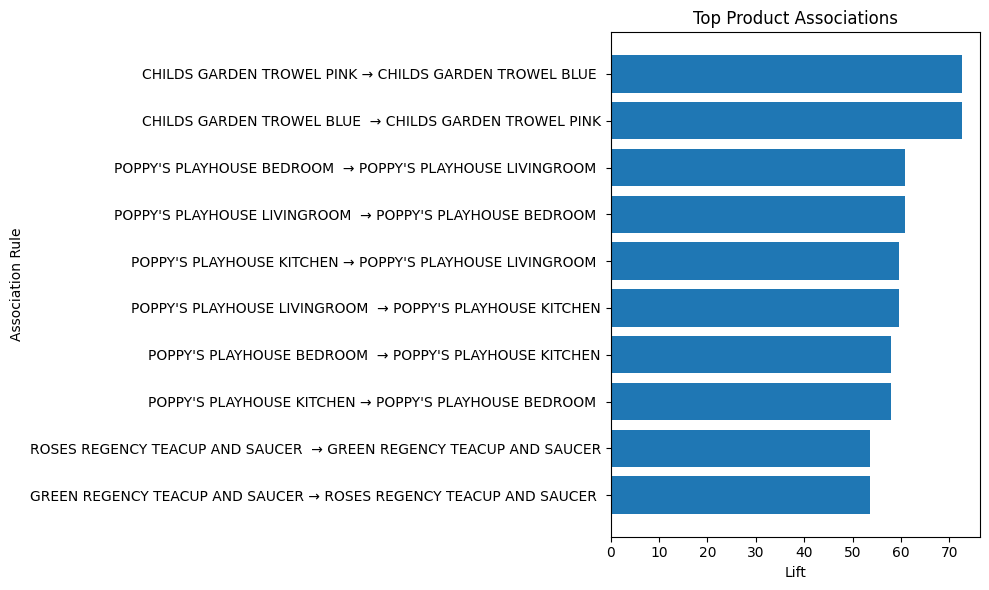

In [26]:
import matplotlib.pyplot as plt

plot_data = top_rules.head(10).copy()

plot_data["rule"] = (
    plot_data["antecedents"]
    + " → "
    + plot_data["consequents"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["rule"],
    plot_data["lift"]
)

plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top Product Associations")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()